### This notebook defines the covariates to be used in the analysis to assess ecosystem condition.

In [4]:
import ee

ee.Authenticate(auth_mode='notebook')
ee.Initialize(project = 'ee-gsingh')

import geemap
from geeml.utils import eeprint
import geopandas as gpd
import pandas as pd
import numpy as np
import json
from shapely import wkt
from tqdm.auto import tqdm
import os
import time
from functools import wraps

1. Structure covariates

In [2]:
# Hunter et al., 2025. 2000-2022

h2000 = ee.ImageCollection("projects/global-pasture-watch/assets/gsvh-30m/v1/short-veg-height_m").filterDate('2000').first()
h2022 = ee.ImageCollection("projects/global-pasture-watch/assets/gsvh-30m/v1/short-veg-height_m").filterDate('2022').first()

# Lang et al., 2023. 2020
canopy_height = ee.Image("users/nlang/ETH_GlobalCanopyHeight_2020_10m_v1")

In [3]:
# combine short height (<10m) from hunter et al., 2025 with canopy height (>10m) from lang et al., 2023
cheight22 = h2022.updateMask(h2022.lte(10)).unmask(canopy_height).rename('comp_height_2022').toFloat()

# Zoom to south africa
Map = geemap.Map(center=[-30, 25], zoom=5)
viridis = ['#440154', '#482878', '#3E4989', '#31688E', '#26828E', '#1F9E89', '#35B779', '#6DCD59', '#B4DE2C', '#FDE725']
Map.addLayer(h2022, {'palette':viridis, 'min':0, 'max': 30}, 'h2022')
Map.addLayer(canopy_height,{'palette':viridis, 'min':0, 'max': 30}, 'canopy_height')
Map.addLayer(cheight22, {'palette':viridis, 'min':0, 'max': 30}, 'cheight22')

Map

Map(center=[-30, 25], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tra…

2. Function covariates

In [4]:
# Isik, M. S., Parente, L., Consoli, D., Sloat, L., Mesquita, V. V., Ferreira, L. G., Sabbatini, S., Stanimirova, R., Teles, N. M., Robinson, N., Costa Junior, C., & Hengl, T. (2025).
# Light use efficiency (LUE) based bimonthly gross primary productivity (GPP) for global grasslands at 30 m spatial resolution (2000–2022).
# PeerJ, 13, e19774. https://doi.org/10.7717/peerj.19774

ugpp_m2000 = ee.ImageCollection("projects/global-pasture-watch/assets/ggpp-30m/v1/ugpp_m").filterDate('2000').first()
ugpp_m2022 = ee.ImageCollection("projects/global-pasture-watch/assets/ggpp-30m/v1/ugpp_m").filterDate('2022').first()

3. Composition covariates

In [5]:

# Define the ImageCollections and mask
bii8km = ee.ImageCollection("projects/ee-geethensingh/assets/Hayley/BII_8km")
bii1km = ee.ImageCollection("projects/ee-geethensingh/assets/Hayley/BII_1km")
mask = ee.Image("projects/ee-geethensingh/assets/BIIMask")

# Define the band names
bands1km = ['Land Use', 'Land Use Intensity', 'BII All',
            'BII Amphibians', 'BII Birds', 'BII Forbs', 'BII Graminoids',
            'BII Mammals', 'BII All Plants', 'BII Reptiles', 'BII Trees',
            'BII All Vertebrates']

bands8km = ['BII All',
            'BII Amphibians', 'BII Birds', 'BII Forbs', 'BII Graminoids',
            'BII Mammals', 'BII All Plants', 'BII Reptiles', 'BII Trees',
            'BII All Vertebrates', 'Land Use', 'Land Use Intensity']

# Rename bands for 1km data
bii1km = bii1km.toBands().rename(bands1km)

# Remove no data pixels for 1km data
biionekm = bii1km.select('^BII.*').selfMask()

# Remove land uses (plantation and protected area) with no intensity for 1km data
lcMask = bii1km.select('Land Use').neq(2).And(
    bii1km.select('Land Use').neq(5))
LUI = bii1km.select('Land Use Intensity').updateMask(lcMask)

# Merge datasets for 1km data
bii1km = biionekm.addBands([bii1km.select('Land Use'), LUI]).updateMask(mask)

# Rename bands for 8km data
bii8km = bii8km.toBands().rename(bands8km)

# Remove no data pixels for 8km data
biieightkm = bii8km.select('^BII.*').selfMask()

# Remove land uses (plantation and protected area) with no intensity for 8km data
lcMask = bii8km.select('Land Use').neq(2).And(
    bii8km.select('Land Use').neq(5))
LUI = bii8km.select('Land Use Intensity').updateMask(lcMask)

# Merge datasets for 8km data
bii8km = biieightkm.addBands([bii8km.select('Land Use'), LUI]).updateMask(mask)

## Step 2: Create feature coverage samples

In [6]:
covariates = cheight22.rename('structure').addBands([ugpp_m2022.rename('function'), bii1km.select('BII All').rename('composition')])#.updateMask(ag_bin)

In [7]:
# import lsib and filter to south africa
sa = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017").filter(ee.Filter.eq('country_na', 'South Africa'))

grid = sa.geometry().coveringGrid(sa.geometry().projection(), 10000)
Map = geemap.Map()
Map.addLayer(grid, {}, 'grid')
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [4]:
test = ee.Feature(grid.toList(1, 2).get(0)).geometry()
Map.addLayer(test, {}, 'test')

In [ ]:
# Load South Africa polygon
sa = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017") \
        .filter(ee.Filter.eq('country_na', 'South Africa'))

# Create grid over SA
grid = sa.geometry().coveringGrid(sa.geometry().projection(), 10000)

# Function to calculate % of cell overlapping SA
def cell_land_fraction(cell):
    cell_geom = ee.Feature(cell).geometry()
    
    # Intersection area
    intersect_area = cell_geom.intersection(sa.geometry(), 10).area(10)
    cell_area = cell_geom.area(10)
    
    # Fraction in %
    fraction = intersect_area.divide(cell_area).multiply(100)
    
    return ee.Feature(cell).set({'land_frac': fraction})

# Map over grid
grid_with_frac = ee.FeatureCollection(grid).map(cell_land_fraction)

# Filter cells with >= 50% land
grid_filtered = grid_with_frac.filter(ee.Filter.gte('land_frac', 50))

# Optional: print or visualize
# print(grid_filtered.size().getInfo())
Map.addLayer(grid_filtered, {}, 'grid_filtered')


In [332]:
# -----------------------------
# Parameters
# -----------------------------
n = 500
nClusters = 15
clusterSeq = ee.List.sequence(0, nClusters - 1)
geometry = test  # define your geometry
clipped = covariates.clip(geometry)       # your multiband image
Map = geemap.Map()
Map.addLayer(clipped, {}, 'clipped', False)

# -----------------------------
# Generate random points & sample data
# -----------------------------
pts = ee.FeatureCollection.randomPoints(geometry, n, 42, 30)
initData = clipped.sampleRegions(collection=pts, scale=30)
Map.addLayer(pts, {}, 'Initialise points', False)

# -----------------------------
# Train KMeans clusterer
# -----------------------------
model = ee.Clusterer.wekaKMeans(nClusters=nClusters, init=1, seed=42)
model = model.train(initData, clipped.bandNames())

# Cluster image
clusters = clipped.cluster(model).rename('cluster')
scale = clusters.projection().nominalScale()
# eeprint(clusters.reduceRegion(
#     reducer=ee.Reducer.countDistinct(),
#     geometry=geometry,
#     scale=30,
#     maxPixels=1e13
# ))
Map.addLayer(clusters.randomVisualizer(), {}, 'clusters', False)

# -----------------------------
# Compute centroids (mean values per cluster)
# -----------------------------
centroids = clipped.addBands(clusters).reduceRegion(
    reducer=ee.Reducer.mean().repeat(3).group(groupField=3, groupName='cluster'),
    geometry=geometry,
    scale= scale,
    maxPixels=1e13
)
# eeprint(centroids)
# -----------------------------
# Helper functiom: To convert multiband image → image collection of single bands
# -----------------------------
def image_to_collection(image):
    band_names = image.bandNames()
    return ee.ImageCollection.fromImages(
        band_names.map(lambda b: image.select([b]).rename(['val']))
    )

# -----------------------------
# Compute squared distance from each pixel to its cluster centroid
# -----------------------------
def cluster_diff(clusterid):
    clusterid = ee.Number(clusterid)
    centroid = ee.Dictionary(
        ee.List(centroids.get('groups')).get(clusterid)
    ).get('mean')
    diff = clipped.updateMask(clusters.eq(clusterid)).subtract(ee.Image.constant(centroid))
    return image_to_collection(diff.pow(2)).sum()# sum of image with 3 bands (sum of squared diffs across each covariate)

diffs = ee.ImageCollection(clusterSeq.map(cluster_diff)) # for each cluster, an image of sum of squared diffs
# eeprint(diffs)

# # -----------------------------
# # Find pixels closest to centroids
# # -----------------------------
sample_mins = diffs.toBands().reduceRegion(
    reducer=ee.Reducer.min(),
    geometry=geometry,
    scale=scale,
    maxPixels=1e13
)
# eeprint(sample_mins)

# # -----------------------------
# # Extract sample points for each cluster
# # -----------------------------
def extract_samples(clusterid):
    clusterid = ee.Number(clusterid).toInt()
    # Extract the min distance value for this cluster
    closest = sample_mins.getNumber(ee.Algorithms.String(clusterid).cat('_val'))
    points = diffs.toBands().select([clusterid]).eq(ee.Image.constant(closest)).selfMask()
    samples = points.sample(region = geometry, scale = scale, seed = 42, geometries = True)
    # samples = points.reduceToVectors(
    #     reducer=ee.Reducer.countEvery(),
    #     geometry=geometry,
    #     # crs='EPSG:4326',
    #     scale=30,
    #     geometryType='centroid',
    #     maxPixels=1e13
    # )
    return samples.first()

samples = ee.FeatureCollection(clusterSeq.map(extract_samples))#.flatten()
eeprint(samples.size())

# # -----------------------------
# # Visualization (optional)
# # -----------------------------
# Map.centerObject(geometry, 10)
# Map.addLayer(samples, {}, 'FC Sample points', False)
# Map


In [3]:
Map = geemap.Map()
Map.addLayer(clusters.randomVisualizer(), {}, 'clusters', False)
Map.addLayer(points)
Map.addLayer(ee.Feature(samples))
Map.centerObject(samples.geometry(), 14)
Map

NameError: name 'clusters' is not defined

In [327]:
cid = 0
diff = cluster_diff(cid)
sample_min = diff.reduceRegion(
    reducer=ee.Reducer.min(),
    geometry=geometry,
    scale=27.8298,
    maxPixels=1e13
)
closest = sample_mins.getNumber(ee.Algorithms.String(cid).cat('_val'))
points = diff.eq(ee.Image.constant(closest)).selfMask().rename('points')
# samples = points.sample(region = test, scale = 30, seed = 42, geometries = True).first()
# samples = points.stratifiedSample(numPoints = 1, classBand = 'points', region = test,
#                                    scale=30,  seed = 30, geometries = True).first()
# eeprint(samples)
# samples = points.reduceToVectors(
#     reducer=ee.Reducer.countEvery(),
#     geometry=geometry,
#     crs='EPSG:4326',
#     scale=30,
#     geometryType='centroid',
#     maxPixels=1e13
# ).first()
# eeprint(samples)
samples = extract_samples(cid)

eeprint(clusters.reduceRegion(reducer = ee.Reducer.mean(), geometry=samples.geometry(), scale=30))

In [3]:
def FSCS(
    covariates: ee.Image,
    n_clusters: int,
    n_init_points: int,
    geometry: ee.Geometry,
    scale: int = 30,
    seed: int = 42
) -> ee.FeatureCollection:
    """
    Performs Feature Space Coverage Sampling (FSCS) on the provided multiband covariate image.

    The function uses KMeans clustering on a random sample of points within the given geometry,
    computes per-cluster centroids, and identifies the pixels closest to each centroid 
    (representative of feature-space centers).

    Args:
        covariates (ee.Image): Multiband image containing covariates for clustering.
        n_clusters (int): Number of KMeans clusters to form.
        n_init_points (int): Number of random points for KMeans initialization.
        geometry (ee.Geometry): Area of interest to clip and sample.
        scale (int, optional): Pixel scale in meters for sampling and clustering. Default = 30.
        seed (int, optional): Random seed for reproducibility. Default = 42.

    Returns:
        ee.FeatureCollection: FeatureCollection of sample points closest to cluster centroids.
    """

    # -----------------------------
    # Clip input to geometry
    # -----------------------------
    clipped = covariates.clip(geometry)

    # -----------------------------
    # Generate random initialization points and sample image
    # -----------------------------
    init_points = ee.FeatureCollection.randomPoints(
        region=geometry,
        points=n_init_points,
        seed=seed,
        maxError=scale
    )
    init_data = clipped.sampleRegions(collection=init_points, scale=scale)

    # -----------------------------
    # Train KMeans clusterer
    # -----------------------------
    clusterer = ee.Clusterer.wekaKMeans(nClusters=n_clusters, init=1, seed=seed)
    clusterer = clusterer.train(init_data, clipped.bandNames())

    # Apply trained model
    clusters = clipped.cluster(clusterer).rename('cluster')
    scale = 10#clusters.projection().nominalScale()

    # -----------------------------
    # Compute centroids (mean values per cluster)
    # -----------------------------
    centroids = clipped.addBands(clusters).reduceRegion(
        reducer=ee.Reducer.mean()
        .repeat(clipped.bandNames().size())
        .group(groupField=clipped.bandNames().size(), groupName='cluster'),
        geometry=geometry,
        scale=scale,
        maxPixels=1e13
    )

    # -----------------------------
    # Helper: Convert multiband image → collection of single-band images
    # -----------------------------
    def image_to_collection(image: ee.Image) -> ee.ImageCollection:
        band_names = image.bandNames()
        return ee.ImageCollection.fromImages(
            band_names.map(lambda b: image.select([b]).rename(['val']))
        )

    # -----------------------------
    # Compute squared distance of each pixel to its cluster centroid
    # -----------------------------
    def cluster_diff(cluster_id: ee.Number) -> ee.Image:
        cluster_id = ee.Number(cluster_id)
        centroid_dict = ee.Dictionary(
            ee.List(centroids.get('groups')).get(cluster_id)
        ).get('mean')
        diff = clipped.updateMask(clusters.eq(cluster_id)).subtract(ee.Image.constant(centroid_dict))
        return image_to_collection(diff.pow(2)).sum()  # Sum of squared diffs across covariates

    cluster_seq = ee.List.sequence(0, n_clusters - 1)
    diffs = ee.ImageCollection(cluster_seq.map(cluster_diff))

    # -----------------------------
    # Find pixels closest to centroids
    # -----------------------------
    sample_mins = diffs.toBands().reduceRegion(
        reducer=ee.Reducer.min(),
        geometry=geometry,
        scale=scale,
        maxPixels=1e13
    )

    # -----------------------------
    # Extract representative points per cluster
    # -----------------------------
    def extract_samples(cluster_id: ee.Number) -> ee.FeatureCollection:
        cluster_id = ee.Number(cluster_id).toInt()
        closest_val = sample_mins.getNumber(ee.String(cluster_id).cat('_val'))
        points = clusters.updateMask(diffs.toBands().select([cluster_id]).eq(ee.Image.constant(closest_val))).rename('points')#)
        return points

    # -----------------------------
    # Collect and return all sample points
    # -----------------------------
    tosample = ee.Image(ee.ImageCollection(cluster_seq.map(extract_samples)).max()).rename('toSample')
    samples = tosample.stratifiedSample(numPoints = 1, classBand = 'toSample', region = geometry,
                                   scale=scale,  seed = seed, geometries = True)

    return clusters, samples


In [8]:
# import lsib and filter to south africa
sa = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017").filter(ee.Filter.eq('country_na', 'South Africa'))

# Ecoregions
ecoregions = ee.FeatureCollection("RESOLVE/ECOREGIONS/2017").filterBounds(sa.geometry())

econames = ecoregions.aggregate_array('ECO_NAME')
econames

listid = 6
econame = ecoregions.aggregate_array('ECO_NAME').get(listid).getInfo()
print(f"Selecting {econame} ecoregion")
ecoregion = ecoregions.filter(ee.Filter.eq('ECO_NAME', econame))

Selecting Highveld grasslands ecoregion


In [9]:
ecoregion.geometry().area(10).divide(1e6).getInfo()  # area in km2

242015.7489714492

In [6]:
AEF = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")

AEF22 = AEF.filterDate("2022-01-01", "2023-01-01").filterBounds(ecoregion.geometry()).mosaic()

In [39]:
AEF22.projection().nominalScale()

In [33]:
clusters, samples = FSCS(
    covariates=AEF22,
    n_clusters=2,
    n_init_points=500,
    geometry=grid_filtered.filterBounds(ecoregion.geometry()).limit(1).geometry(),
    scale=10,
    seed = 42
)
# eeprint(samples.size())

In [34]:
eeprint(samples)

In [23]:
test = AEF22.reduceRegions(collection = samples, reducer = ee.Reducer.mean(), scale = clusters.projection().nominalScale()).select(AEF22.bandNames())
df = ee.data.computeFeatures({
    'expression': test,
    'fileFormat': 'GEOPANDAS_GEODATAFRAME'
})

# Need to set the CRS.
# Make sure it matches the CRS of FeatureCollection geometries.
df.crs = 'EPSG:4326'
df


,geometry,A00,A01,A02,A03,A04,A05,A06,A07,A08,...,A54,A55,A56,A57,A58,A59,A60,A61,A62,A63
0,POINT (25.5 -32.5),0.038447,0.228897,0.010396,0.024606,-0.166336,-0.055363,0.098424,0.251965,0.075356,...,0.055363,-0.166336,-0.013841,-0.141730,-0.130165,-0.004983,0.103406,0.135886,0.038447,-0.029773
1,POINT (26.5 -32.5),0.124567,0.179377,0.022207,-0.007443,-0.108512,-0.088827,0.135886,0.276140,0.113741,...,0.017778,-0.186082,-0.024606,-0.113741,-0.103406,0.007443,0.088827,0.119093,0.024606,-0.062991


In [19]:
Map = geemap.Map()
Map.addLayer(clusters.randomVisualizer(), {}, 'clusters', False)
Map.addLayer(samples, {}, 'FC Sample points', False)
Map.centerObject(test, 14)
Map

Map(center=[-27.000882504268198, 27.00222333705499], controls=(WidgetControl(options=['position', 'transparent…

In [66]:
# --- Configuration ---
output_csv = "fscs_AEF_samples.csv"
failed_csv = "failed_AEF_cells.csv"
overwrite = True  # Set True to start from scratch
ROWS_PER_CELL = 100  # expected rows per cell

# --- Retry decorator ---
def retry(exceptions, tries=3, delay=10, backoff=2):
    """Retry decorator with exponential backoff."""
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            _tries, _delay = tries, delay
            while _tries > 1:
                try:
                    return func(*args, **kwargs)
                except exceptions as e:
                    print(f"⚠️ {e} — retrying in {_delay}s...")
                    time.sleep(_delay)
                    _tries -= 1
                    _delay *= backoff
            # Final attempt — let it raise if still failing
            return func(*args, **kwargs)
        return wrapper
    return decorator

# --- Resume logic ---
if overwrite:
    for f in [output_csv, failed_csv]:
        if os.path.exists(f):
            os.remove(f)
    start_cell = 0
    header_written = False
else:
    if os.path.exists(output_csv):
        n_rows = sum(1 for _ in open(output_csv)) - 1  # exclude header
        start_cell = max(0, n_rows // ROWS_PER_CELL)
        header_written = True
    else:
        start_cell = 0
        header_written = False

n_cells = 3305
print(f"Resuming from cell {start_cell}/{n_cells}")

# --- Function to process one cell ---
@retry(Exception, tries=3, delay=15, backoff=2)
def process_cell(cell_index):
    selectCell = ee.Feature(grid.filterBounds(ecoregion.geometry()).toList(1, cell_index).get(0)).geometry()
    
    clusters, samples = FSCS(
        covariates=AEF22,
        n_clusters=ROWS_PER_CELL,
        n_init_points=500,
        geometry=selectCell,
        scale=10,
        seed=42
    )

    data = AEF22.reduceRegions(
        collection=samples,
        reducer=ee.Reducer.mean(),
        scale=clusters.projection().nominalScale()
    ).select(AEF22.bandNames())

    df = ee.data.computeFeatures({
        'expression': data,
        'fileFormat': 'GEOPANDAS_GEODATAFRAME'
    })
    df['geometry'] = df['geometry'].apply(lambda g: g.wkt)
    return df


# --- Main loop ---
for cell in tqdm(range(start_cell, n_cells)):
    try:
        df = process_cell(cell)
        df.to_csv(output_csv, mode='a', index=False, header=not header_written)
        header_written = True
    except Exception as e:
        print(f"❌ Cell {cell} failed after retries: {e}")
        # Log failed cells
        with open(failed_csv, "a") as f:
            f.write(f"{cell},{str(e).replace(',', ';')}\n")
        continue


Resuming from cell 0/3305


  0%|          | 0/3305 [00:00<?, ?it/s]

⚠️ Computation timed out. — retrying in 15s...


KeyboardInterrupt: 

In [9]:
import os
import ee
import csv
import time
import logging
import warnings
import threading
from tqdm import tqdm, TqdmWarning
from concurrent.futures import ThreadPoolExecutor, as_completed
from functools import wraps
from contextlib import contextmanager

# --- Initialize Earth Engine using the High Volume endpoint ---
ee.Authenticate(auth_mode='notebook')
ee.Initialize(project = 'ee-gsingh', opt_url='https://earthengine-highvolume.googleapis.com')

# --- Configuration ---
output_csv = "fscs_AEF_samples.csv"
failed_csv = "failed_AEF_cells.csv"
overwrite = False
ROWS_PER_CELL = 100
MAX_WORKERS = 8  # adjust depending on quota and CPU cores
n_cells = 3305

grid_list = grid.filterBounds(ecoregion.geometry()).toList(n_cells)

# --- Retry Decorator ---
def retry(exceptions, tries=3, delay=10, backoff=2):
    """Retry decorator with exponential backoff."""
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            _tries, _delay = tries, delay
            while _tries > 1:
                try:
                    return func(*args, **kwargs)
                except exceptions as e:
                    print(f"⚠️ {e} — retrying in {_delay}s...")
                    time.sleep(_delay)
                    _tries -= 1
                    _delay *= backoff
            return func(*args, **kwargs)
        return wrapper
    return decorator

# --- Resume Logic ---
if overwrite:
    for f in [output_csv, failed_csv]:
        if os.path.exists(f):
            os.remove(f)
    start_cell = 0
else:
    if os.path.exists(output_csv):
        n_rows = sum(1 for _ in open(output_csv)) - 1
        start_cell = max(0, n_rows // ROWS_PER_CELL)
    else:
        start_cell = 0

print(f"Resuming from cell {start_cell}/{n_cells}")

# --- Thread-safe CSV writing ---
csv_lock = threading.Lock()

# --- Context Manager for tqdm logging redirect ---
@contextmanager
def logging_redirect_tqdm(loggers):
    class TqdmLoggingHandler(logging.Handler):
        def emit(self, record):
            tqdm.write(self.format(record))
    handlers = []
    for logger in loggers:
        handler = TqdmLoggingHandler()
        logger.addHandler(handler)
        handlers.append(handler)
    try:
        yield
    finally:
        for logger, handler in zip(loggers, handlers):
            logger.removeHandler(handler)

# --- Process one cell ---
@retry(Exception, tries=3, delay=15, backoff=2)
def process_cell(cell_idx):
    """Process a single grid cell and append its data to CSV."""
    selectCell = ee.Feature(grid_list.get(cell_idx)).geometry()

    clusters, samples = FSCS(
        covariates=AEF22,
        n_clusters=ROWS_PER_CELL,
        n_init_points=500,
        geometry=selectCell,
        scale=10,
        seed=42
    )

    data = AEF22.reduceRegions(
        collection=samples,
        reducer=ee.Reducer.mean(),
        scale=10#clusters.projection().nominalScale()
    ).select(AEF22.bandNames())

    # --- Use High Volume endpoint for computeFeatures ---
    params = {
        'expression': data,
        'fileFormat': 'GEOPANDAS_GEODATAFRAME'
    }
    df = ee.data.computeFeatures(params)

    # --- Append results to CSV (thread-safe) ---
    with csv_lock:
        file_exists = os.path.isfile(output_csv)
        df['cell_index'] = cell_idx  # optional for tracking
        df.to_csv(output_csv, mode='a', index=False, header=not file_exists)


# --- Parallel Execution ---
warnings.filterwarnings('ignore', category=TqdmWarning)
progress_format = '{desc}: |{bar}| [{percentage:5.1f}%] in {elapsed:>5s} (eta: {remaining:>5s})'

with logging_redirect_tqdm([logging.getLogger(__package__)]):
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = [executor.submit(process_cell, i) for i in range(start_cell, n_cells)]

        with tqdm(total=len(futures), desc='Extracting', bar_format=progress_format, dynamic_ncols=True) as bar:
            try:
                for future in as_completed(futures):
                    try:
                        future.result()
                    except Exception as e:
                        with open(failed_csv, "a", newline='') as f:
                            writer = csv.writer(f)
                            writer.writerow([futures[future], str(e).replace(",", ";")])
                    bar.update(1)
            except KeyboardInterrupt:
                print("🛑 Cancelling...")
                executor.shutdown(wait=False, cancel_futures=True)
                raise

print("✅ Extraction complete.")


Resuming from cell 3299/3305


Extracting: |          | [  0.0%] in 00:00 (eta:     ?)

⚠️ List.get: List index must be between 0 and 3299, or -3300 and -1. Found 3301. — retrying in 15s...
⚠️ List.get: List index must be between 0 and 3299, or -3300 and -1. Found 3302. — retrying in 15s...


Extracting: |█▋        | [ 16.7%] in 01:26 (eta: 07:11)

⚠️ List.get: List index must be between 0 and 3299, or -3300 and -1. Found 3300. — retrying in 15s...
⚠️ List.get: List index must be between 0 and 3299, or -3300 and -1. Found 3304. — retrying in 15s...
⚠️ List.get: List index must be between 0 and 3299, or -3300 and -1. Found 3303. — retrying in 15s...
⚠️ List.get: List index must be between 0 and 3299, or -3300 and -1. Found 3301. — retrying in 30s...
⚠️ List.get: List index must be between 0 and 3299, or -3300 and -1. Found 3302. — retrying in 30s...
⚠️ List.get: List index must be between 0 and 3299, or -3300 and -1. Found 3303. — retrying in 30s...
⚠️ List.get: List index must be between 0 and 3299, or -3300 and -1. Found 3304. — retrying in 30s...
⚠️ List.get: List index must be between 0 and 3299, or -3300 and -1. Found 3300. — retrying in 30s...


Extracting: |█▋        | [ 16.7%] in 04:26 (eta: 22:13)


TypeError: list indices must be integers or slices, not Future

In [6]:
# Load South Africa polygon
sa = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017") \
        .filter(ee.Filter.eq('country_na', 'South Africa'))

# Create grid over SA
grid = ecoregion.geometry().coveringGrid(sa.geometry().projection(), 10000)

In [7]:
grid.size()

In [62]:
# --- Function to process one cell ---
@retry(Exception, tries=3, delay=15, backoff=2)
def process_cell(cell_index):
    selectCell = ee.Feature(grid.filterBounds(ecoregion.geometry()).toList(1, cell_index).get(0)).geometry()
    
    clusters, samples = FSCS(
        covariates=AEF22,
        n_clusters=50,
        n_init_points=500,
        geometry=selectCell,
        scale=10,
        seed=42
    )

    data = AEF22.reduceRegions(
        collection=samples,
        reducer=ee.Reducer.mean(),
        scale=clusters.projection().nominalScale()
    ).select(AEF22.bandNames())

    df = ee.data.computeFeatures({
        'expression': data,
        'fileFormat': 'GEOPANDAS_GEODATAFRAME'
    })
    df['geometry'] = df['geometry'].apply(lambda g: g.wkt)
    return df

# --- Main loop ---
for cell in tqdm(range(4,5)):
    print(cell)
    try:
        df = process_cell(cell)
        df.to_csv(output_csv, mode='a', index=False, header=not header_written)
        header_written = True
    except Exception as e:
        print(f"❌ Cell {cell} failed after retries: {e}")
        # Log failed cells
        with open(failed_csv, "a") as f:
            f.write(f"{cell},{str(e).replace(',', ';')}\n")
        continue

  0%|          | 0/1 [00:00<?, ?it/s]

4


In [10]:
# Later, read CSV and convert WKT back to geometry
output_csv = "fscs_AEF_samples.csv"
df_full = pd.read_csv(output_csv)
gdf = gpd.GeoDataFrame(df_full, geometry=df_full['geometry'].apply(wkt.loads), crs='EPSG:4326')

In [11]:
gdf.shape

(330000, 66)

In [12]:
gdf_clean = gdf.drop_duplicates(subset='geometry')

# --- 4. Save as shapefile ---
output_shp = "fscs_aef_samples.shp"
gdf_clean.to_file(output_shp, driver='ESRI Shapefile')

print(f"✅ Saved cleaned shapefile: {output_shp}")
print(f"Original rows: {len(gdf)}, after deduplication: {len(gdf_clean)}")

✅ Saved cleaned shapefile: fscs_aef_samples.shp
Original rows: 330000, after deduplication: 329600


## Step 3: Define footprint of transformed variables

In [7]:
# 1 = natural or near natural ecosystems
# 2 = secondary natural area (previously cropland or mine or builtup, now revegetated partially)
# 3 = artificial water body (dams and water treatment)
# 4 = builtup (villages, urban, inductrial, commercial and infrastructure) 
# 5 = cropland 
# 6 = mine
# 7 = plantation (alien timber and pulp plantations)

sanlc22 = ee.Image("projects/ee-gsingh/assets/RECOVER/sanlc2022_7class").rename('nlc22')
reclass = sanlc22.remap(ee.List.sequence(1, 7), ee.List([0,0,0,1,2,3,4])).rename('nlc22_reclass')
Map = geemap.Map(center=[-30, 25], zoom=5)
Map.addLayer(sanlc22, {'min':1, 'max':7, 'palette':["#7c7c73","#868987","#a2a8a9",'#2c7fb8','#253494','#081d58','#081d58']}, 'original', True)
Map.addLayer(reclass, {'min':0, 'max':4, 'palette':["#7c7c73",'#2c7fb8','#253494','#081d58','#081d58']}, 'reclass', True)
Map

Map(center=[-30, 25], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tra…

## Step 4: Fit minDistClassifier models

In [8]:
# import lsib and filter to south africa
sa = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017").filter(ee.Filter.eq('country_na', 'South Africa'))

# Ecoregions
ecoregions = ee.FeatureCollection("RESOLVE/ECOREGIONS/2017").filterBounds(sa.geometry())

In [9]:
econames = ecoregions.aggregate_array('ECO_NAME')
econames

In [10]:
listid = 6
econame = ecoregions.aggregate_array('ECO_NAME').get(listid).getInfo()
print(f"Selecting {econame} ecoregion")
ecoregion = ecoregions.filter(ee.Filter.eq('ECO_NAME', econame))

Selecting Highveld grasslands ecoregion


In [11]:
# fscs = ee.FeatureCollection("projects/ee-gsingh/assets/RECOVER/fscs_samples_v1").filterBounds(ecoregion.geometry())
fscs = ee.FeatureCollection("projects/ee-gsingh/assets/RECOVER/fscs_aef_samples").filterBounds(ecoregion.geometry())

eeprint(fscs.size())
eeprint(fscs.first())
train = reclass.reduceRegions(collection = fscs, reducer = ee.Reducer.first(), scale = reclass.projection().nominalScale())
    # .filter(ee.Filter.notNull(['first', 'compositio']))
train.first()

In [12]:
bandNames = ['A00',
 'A01',
 'A02',
 'A03',
 'A04',
 'A05',
 'A06',
 'A07',
 'A08',
 'A09',
 'A10',
 'A11',
 'A12',
 'A13',
 'A14',
 'A15',
 'A16',
 'A17',
 'A18',
 'A19',
 'A20',
 'A21',
 'A22',
 'A23',
 'A24',
 'A25',
 'A26',
 'A27',
 'A28',
 'A29',
 'A30',
 'A31',
 'A32',
 'A33',
 'A34',
 'A35',
 'A36',
 'A37',
 'A38',
 'A39',
 'A40',
 'A41',
 'A42',
 'A43',
 'A44',
 'A45',
 'A46',
 'A47',
 'A48',
 'A49',
 'A50',
 'A51',
 'A52',
 'A53',
 'A54',
 'A55',
 'A56',
 'A57',
 'A58',
 'A59',
 'A60',
 'A61',
 'A62',
 'A63']
# bandNames = ['structure', 'function', 'compositio']
classifier = ee.Classifier.minimumDistance(metric = 'cosine').train(
    features = train,
    classProperty = 'first',
    inputProperties = bandNames).setOutputMode('RAW')

Map = geemap.Map(center=[-30, 25], zoom=5)
Map.addLayer(ecoregion)
# Map.addLayer(covariates.rename(['structure', 'function', 'compositio']).clip(ecoregion.geometry()).classify(classifier).arrayFlatten([['natural', 'built', 'crops', 'mines', 'plantation']]), {}, 'MD classification', False)
Map.addLayer(AEF22.clip(ecoregion.geometry()).classify(classifier).arrayFlatten([['natural', 'built', 'crops', 'mines', 'plantation']]), {}, 'MD classification', False)
Map.centerObject(ecoregion, 10)
Map

Map(center=[-27.791878438079546, 27.763014210969725], controls=(WidgetControl(options=['position', 'transparen…

In [16]:
classifier = ee.Classifier.minimumDistance(metric = 'cosine').train(
    features = train,
    classProperty = 'first',
    inputProperties = bandNames)
# Map.addLayer(AEF22.clip(ecoregion.geometry()).classify(classifier).randomVisualizer(), {}, 'MD classification', False)

# Export the MD-classified AEF22 image to an Earth Engine asset.
# Place this after the cell that builds `classifier` and `AEF22` (and `ecoregion`).

classified = AEF22.classify(classifier)

task = ee.batch.Export.image.toAsset(
    image=classified,
    description='export_MD_AEF22_ecoregion',
    assetId='projects/ee-gsingh/assets/RECOVER/AEF22_cosine',
    region=ecoregion.geometry(),
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()
# print(task.status())
# ...existing code...

In [18]:
classified = ee.Image("projects/ee-gsingh/assets/RECOVER/AEF22_cosine")

n_classes = 2
pred_masks = classified.gte(1).eq(ee.Image.constant(ee.List.sequence(0, n_classes - 1)))
true_masks = reclass.gte(1).eq(ee.Image.constant(ee.List.sequence(0, n_classes - 1)))

In [32]:
def iou(true_masks, pred_masks, clsno, grid_filtered):
    """
    Compute global IoU for a specific class across multiple tiles efficiently.

    Args:
        true_masks (ee.Image): ground truth mask image (multi-band)
        pred_masks (ee.Image): predicted mask image (multi-band)
        clsno (int): class index (band number)
        grid_filtered (ee.FeatureCollection): tiling grid

    Returns:
        ee.Number: IoU value for the specified class
    """
    # Select class band
    pred_mask = pred_masks.select([clsno])
    true_mask = true_masks.select([clsno])

    intersection = pred_mask.And(true_mask).selfMask()
    union = pred_mask.Or(true_mask).selfMask()

    # For each group, sum the number of pixels
    sums = intersection.addBands(union).rename(['intersection', 'union']).reduceRegions(
                collection= grid_filtered,
                reducer=ee.Reducer.count(),
                scale= pred_mask.projection().nominalScale(),
                maxPixelsPerRegion=1e9
            )

    # Aggregate totals across all tiles
    totals = sums.reduceColumns(
        reducer=ee.Reducer.sum().repeat(2),
        selectors=['intersection', 'union']
    )

    values = ee.List(totals.get('sum'))
    intersection_count = values.getNumber(0)
    union_count = values.getNumber(1)

    # Compute IoU from aggregated counts
    iou = intersection_count.divide(union_count)

    return ee.Feature(None, {'iou': iou, 'class': clsno})

In [36]:
grid = ecoregion.geometry().coveringGrid(sa.geometry().projection(), 100000)
iouout = iou(true_masks=true_masks, pred_masks=pred_masks, clsno=0, grid_filtered= grid)
# eeprint()

In [37]:
# Export an ee.FeatureCollection to Google Drive.
def export_table_to_drive(fc, description, folder, file_name_prefix, file_format='CSV', selectors=None):
    """
    fc: ee.FeatureCollection
    description: export task description
    folder: Drive folder name (created in your Drive)
    file_name_prefix: output filename prefix
    file_format: 'CSV' or 'SHP' or 'KML' etc.
    selectors: optional list of property names to include
    """
    task = ee.batch.Export.table.toDrive(
        collection=fc,
        description=description,
        folder=folder,
        fileNamePrefix=file_name_prefix,
        fileFormat=file_format,
        selectors=selectors
    )
    task.start()
    print(f"Started Drive export: {description} -> {folder}/{file_name_prefix} ({file_format})")
    return task

# Examples (uncomment and run the one you need):
# export samples from FSCS as CSV
export_table_to_drive(ee.FeatureCollection(iouout), 'export_fscs_samples_csv', 'EE_exports', 'iou_AEF22_c0', file_format='CSV')

Started Drive export: export_fscs_samples_csv -> EE_exports/iou_AEF22_c0 (CSV)


<Task D62FPONCWVTHIYVPEEK5NKY7 Type.EXPORT_TABLE: export_fscs_samples_csv (State.UNSUBMITTED)>

In [ ]:
np.array([0.6382988917, 0.4203138482]).mean()

np.float64(0.52930636995)

: 

## Step 5: Calulate dissimilarity to transformed variables

In [15]:
dissimilarity = covariates.rename(['structure', 'function', 'compositio'])\
    .clip(ecoregion.geometry())\
        .classify(classifier)\
            .arrayFlatten([['natural', 'built', 'crops', 'mines', 'plantation']])


In [24]:
def compute_min_max(image, bands, feature_collection, geometry, scale=None):
    """
    Compute min and max values for each band in 'bands' within the given geometry.

    Args:
        image (ee.Image): Input image.
        bands (list): List of band names, e.g. ['built', 'crops', 'mines', 'plantation'].
        feature_collection (ee.FeatureCollection): Collection to reduce over.
        geometry (ee.Geometry): Geometry to bound the operation.
        scale (float, optional): Pixel scale; defaults to image nominal scale.

    Returns:
        dict: {'band': {'min': value, 'max': value}, ...}
    """
    scale = scale or image.projection().nominalScale()
    results = {}

    for band in tqdm(bands):
        band_img = image.select(band)
        fc = feature_collection.filterBounds(geometry.bounds())
        min_fc = band_img.reduceRegions(
            collection=fc,
            reducer=ee.Reducer.min(),
            scale=scale,
            maxPixelsPerRegion=1e9
        )
        max_fc = band_img.reduceRegions(
            collection=fc,
            reducer=ee.Reducer.max(),
            scale=scale,
            maxPixelsPerRegion=1e9
        )

        min_val = ee.Number(min_fc.aggregate_min('min')).getInfo()
        max_val = ee.Number(max_fc.aggregate_max('max')).getInfo()
        results[band] = {'min': min_val, 'max': max_val}

    return results


In [ ]:
from tqdm.auto import tqdm
bands = ['natural', 'built', 'crops', 'mines', 'plantation']
stats = compute_min_max(
    image=dissimilarity,
    bands=bands,
    feature_collection=grid_filtered,
    geometry=ecoregion.geometry()
)
print(stats)


In [16]:
bands = ['natural', 'built', 'crops', 'mines', 'plantation']
stats = {'natural': {'min': 0.002415160155396806, 'max': 8.213011304192195}, 'built': {'min': 0.029192500304881984, 'max': 10.572091507839609}, 'crops': {'min': 0.03555272122984671, 'max': 11.124487772450635}, 'mines': {'min': 0.09214627853406042, 'max': 15.451381799991877}, 'plantation': {'min': 0.03634025092056783, 'max': 5.242460059693043}}


In [17]:
eebands = ee.List(bands)
norm = ee.ImageCollection(eebands.map(lambda b: dissimilarity.select([b]).unitScale(
    ee.Dictionary(ee.Dictionary(stats).get(b)).get('min'), ee.Dictionary(ee.Dictionary(stats).get(b)).get('max')))).toBands().rename(bands)
eeprint(norm)

In [ ]:
Map = geemap.Map(center=[-30, 25], zoom=5)
Map.add_basemap('SATELLITE')
Map.addLayer(reclass.randomVisualizer(), {}, 'reclass', False)
Map.addLayer(dissimilarity.select('natural'), {'min':0, 'max':12, 'palette':['green', 'yellow', 'red']}, 'nat_dissim', True)

# Map.addLayer(dissimilarity.select('crops'), {'min':0, 'max':12, 'palette':['green', 'yellow', 'red']}, 'crop_dissim', False)
# Map.addLayer(dissimilarity.select('plantation'), {'min':0, 'max':6, 'palette':['green', 'yellow', 'red']}, 'plan_dissim', False)
# Map.addLayer(norm, {'min':0, 'max':1, 'palette':['green', 'yellow', 'red']}, 'norm_dist', False)
# Map.addLayer(fuzzyOR, {'min':0, 'max':1, 'palette':['green', 'yellow', 'red']}, 'fuzzyOR', False)
Map.centerObject(ecoregion, 7)
Map

Map(center=[-27.791878438079546, 27.763014210969725], controls=(WidgetControl(options=['position', 'transparen…

In [26]:
fuzzyOR = ee.Image.constant(1).subtract(
    ee.Image.constant(1).subtract(norm).reduce(ee.Reducer.product())
)

In [56]:
def fuzzy_or_algebraic(x, stable=True, eps=1e-12):
    """
    Compute the algebraic fuzzy OR (smooth fuzzy mean).

    Parameters
    ----------
    x : np.ndarray
        Membership values in [0, 1].
    stable : bool, optional
        Use log-sum trick for stability.
    eps : float, optional
        Minimum clamp value for (1 - x) to avoid log(0).

    Returns
    -------
    float
        Fuzzy OR result.
    """
    x = np.asarray(x, dtype=float)
    x = np.clip(x, 0, 1)

    if stable:
        log_terms = np.log(np.clip(1 - x, eps, 1))
        sum_logs = np.sum(log_terms)
        prod = np.exp(sum_logs)
    else:
        prod = np.prod(1 - x)

    return 1 - prod

# Example usage
print(fuzzy_or_algebraic([0.1, 0.1, 0.1]))


0.2709999999999999


## Step 6: Ecosystem condition Index

In [23]:
coarse = ee.Image('projects/ee-gsingh/assets/RECOVER/GANVC')
coarseProjection = coarse.projection()

In [24]:
Map.setCenter(-49.265188, -16.602052, 4)

domi_grassland = ee.ImageCollection(
  "projects/global-pasture-watch/assets/ggc-30m/v1/grassland_c"
)
visParams = {"opacity":1, "min":1,"max":2,"palette":["ffcd73","ff9916"]}

domi_grassland_2022 = domi_grassland.filterDate('2022-01-01', '2023-01-01').first()
Map.addLayer(
    domi_grassland_2022.selfMask(), 
    visParams, 'Dominant grassland class (2022)'
)
Map.addLayer(coarse)
Map

Map(center=[-16.602052, -49.265188], controls=(WidgetControl(options=['position', 'transparent_bg'], position=…

In [27]:
coarse = ee.Image('projects/ee-gsingh/assets/RECOVER/GANVC')
grass22 = domi_grassland_2022.gte(1).rename('grass22').updateMask(fuzzyOR.gt(0))

coarseProjectionat930m = coarse.projection().atScale(grass22.projection().nominalScale().multiply(32))#27.8298km
coarseProjectionat27km = coarse.projection().atScale(coarse.projection().nominalScale())#27749.9km

grassProp930 = grass22.reduceResolution(
      reducer= ee.Reducer.mean(),
      maxPixels= 1024
    ).reproject(
      crs = coarseProjectionat930m
    )
grassProp27km = grassProp930.reduceResolution(
      reducer= ee.Reducer.mean(),
      maxPixels= 1024
    ).reproject(
      crs = coarseProjectionat27km
    )
# Map.addLayer(grassProp27km, {min:0, max: 1}, 'grass prop cover at gnv scale')
# Map

In [ ]:
# ECI = F x I (footprint x integrity)
coarseProjectionat300m = coarse.projection().atScale(grass22.projection().nominalScale().multiply(10))#27.8298km
grassProp300 = grass22.reduceResolution(
      reducer= ee.Reducer.mean(),
      maxPixels= 1024
    ).reproject(
      crs = coarseProjectionat930m
    )
grassECI = grassProp300.multiply(ee.Image.constant(1).subtract(norm.select('natural'))).rename('grassECI_2022')
vp = {'bands': ['grassECI_2022'], 'min': 0, 'max': 0.9403109740529666, 'palette': ['#543005', '#563105', '#583305', '#5b3406', '#5d3506', '#5f3606', '#613806', '#633906', '#663a07', '#683c07', '#6a3d07', '#6c3e07', '#6e4007', '#714108', '#734208', '#754308', '#774508', '#794608', '#7c4709', '#7e4909', '#804a09', '#824b09', '#844c09', '#874e0a', '#894f0a', '#8b500a', '#8d520b', '#8f540c', '#91560d', '#93580f', '#955910', '#975b12', '#995d13', '#9b5f14', '#9d6116', '#9f6317', '#a16518', '#a3671a', '#a5691b', '#a76a1d', '#a96c1e', '#ab6e1f', '#ad7021', '#af7222', '#b17423', '#b37625', '#b57826', '#b77928', '#b97b29', '#bb7d2a', '#bd7f2c', '#bf812d', '#c08430', '#c28633', '#c38936', '#c48b3a', '#c58e3d', '#c79040', '#c89343', '#c99546', '#ca9849', '#cc9a4c', '#cd9d50', '#cea053', '#cfa256', '#d1a559', '#d2a75c', '#d3aa5f', '#d4ac62', '#d6af65', '#d7b169', '#d8b46c', '#d9b76f', '#dbb972', '#dcbc75', '#ddbe78', '#dec17b', '#dfc37e', '#e0c481', '#e1c684', '#e2c787', '#e3c989', '#e4ca8c', '#e5cc8f', '#e6cd92', '#e7cf94', '#e8d097', '#e8d29a', '#e9d39d', '#ead59f', '#ebd6a2', '#ecd8a5', '#edd9a8', '#eedbaa', '#efdcad', '#f0deb0', '#f1dfb3', '#f1e1b5', '#f2e2b8', '#f3e4bb', '#f4e5be', '#f5e7c0', '#f6e8c3', '#f6e9c5', '#f6e9c7', '#f6eac9', '#f6eacb', '#f6ebcd', '#f6ebcf', '#f6ecd1', '#f6ecd3', '#f6edd5', '#f6edd7', '#f6eed9', '#f6eedb', '#f5efdc', '#f5efde', '#f5f0e0', '#f5f0e2', '#f5f1e4', '#f5f1e6', '#f5f2e8', '#f5f2ea', '#f5f3ec', '#f5f3ee', '#f5f4f0', '#f5f4f2', '#f5f5f4', '#f4f5f5', '#f2f4f4', '#f0f4f3', '#eff3f3', '#edf3f2', '#ebf3f2', '#e9f2f1', '#e7f2f0', '#e6f1f0', '#e4f1ef', '#e2f0ee', '#e0f0ee', '#def0ed', '#ddefed', '#dbefec', '#d9eeeb', '#d7eeeb', '#d5edea', '#d4ede9', '#d2ede9', '#d0ece8', '#ceece8', '#ccebe7', '#cbebe6', '#c9eae6', '#c7eae5', '#c4e9e4', '#c1e8e2', '#bfe7e1', '#bce5df', '#b9e4de', '#b6e3dd', '#b4e2db', '#b1e1da', '#aee0d8', '#abdfd7', '#a8ddd5', '#a6dcd4', '#a3dbd3', '#a0dad1', '#9dd9d0', '#9ad8ce', '#98d7cd', '#95d6cc', '#92d4ca', '#8fd3c9', '#8dd2c7', '#8ad1c6', '#87d0c5', '#84cfc3', '#81cec2', '#7fccc0', '#7ccabe', '#79c8bc', '#76c6ba', '#73c3b8', '#70c1b6', '#6dbfb4', '#6abdb2', '#67bbb0', '#64b9ae', '#61b7ac', '#5eb5aa', '#5bb3a8', '#58b0a7', '#55aea5', '#52aca3', '#4faaa1', '#4da89f', '#4aa69d', '#47a49b', '#44a299', '#419f97', '#3e9d95', '#3b9b93', '#389991', '#35978f', '#33958d', '#31938b', '#2f9189', '#2d8f87', '#2b8d85', '#298b83', '#278a82', '#258880', '#23867e', '#21847c', '#1f827a', '#1d8078', '#1a7e76', '#187c74', '#167a72', '#147870', '#12766e', '#10746c', '#0e726a', '#0c7169', '#0a6f67', '#086d65', '#066b63', '#046961', '#02675f', '#01655d', '#01645b', '#016259', '#016058', '#015f56', '#015d54', '#015b52', '#015a50', '#01584f', '#01564d', '#01554b', '#015349', '#015147', '#005046', '#004e44', '#004c42', '#004b40', '#00493e', '#00483d', '#00463b', '#004439', '#004337', '#004135', '#003f34', '#003e32', '#003c30']}
Map.addLayer(grassECI, vp, 'grass ECI at 930m', False)
Map


Map(bottom=2617.0, center=[-22.990792513382107, 34.27599371785609], controls=(WidgetControl(options=['position…

In [30]:
# Export grass ECI at 300m to earth engine asset
task = ee.batch.Export.image.toAsset(
    image=grassECI,
    description='export_grassECI_2022_300m_to_asset',
    assetId='projects/ee-gsingh/assets/RECOVER/grassECI_2022_300m',
    region=ecoregion.geometry(),
    scale=grassECI.projection().nominalScale(),
    maxPixels=1e13
)
task.start()
task.status()

{'state': 'READY',
 'description': 'export_grassECI_2022_300m_to_asset',
 'priority': 100,
 'creation_timestamp_ms': 1761572809305,
 'update_timestamp_ms': 1761572809305,
 'start_timestamp_ms': 0,
 'task_type': 'EXPORT_IMAGE',
 'id': '3J2UCV52VQ6CBBAUF6XMJ4RB',
 'name': 'projects/ee-gsingh/operations/3J2UCV52VQ6CBBAUF6XMJ4RB'}

In [32]:
grassECI = ee.Image("projects/ee-gsingh/assets/RECOVER/grassECI_2022_300m")
Map = geemap.Map(center=[-30, 25], zoom=5)
Map.addLayer(grassECI, vp, 'grass ECI from asset', False)
Map

Map(center=[-30, 25], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tra…

## Step 7: Calculate recovery debt

In [ ]:
GANCV = ee.Image('projects/ee-gsingh/assets/RECOVER/GANVC').rename(['grass', 'bare', 'tree'])

RD = GANCV.select('grass').subtract(grassECI)
Map.addLayer(RD, {'min':0, 'max':5, 'palette':['white', 'blue', 'green', 'yellow', 'red']}, 'RD', True)

## Step 8: Compute recovery debt overtime

## Step 9: Validation

## Transformed categories (pressures)

In [341]:
# 2022 agriculture modification at 90 m
HM_90M = ee.ImageCollection("projects/sat-io/open-datasets/GHM/HM_2022_90M")
paletteHM = ['4c6100','adda25','e2ff9b','ffff73','ffe629','ffd37f','ffaa00','e69808','e60000','a80000','730000']

visParams = {'min': 0.0, 'max': 1.0, 'palette': paletteHM}

ag2022_90 = HM_90M.filter(ee.Filter.eq('threat_code', 'AG')).first()
ag_bin = ag2022_90.gte(0.2).rename('ag_2022_90m')
Map.addLayer(ag2022_90, visParams, 'GHM-v3 2022 Agriculture (90m)', False)
Map.addLayer(ag_bin, visParams, 'GHM-v3 2022 Agriculture Bin (90m)', False)
Map

Map(bottom=77714.0, center=[-30.99144273409666, 19.313793182373047], controls=(WidgetControl(options=['positio…

In [25]:
// Load the v3 collections
var HM_OVERALL = ee.ImageCollection("projects/sat-io/open-datasets/GHM/HM_1990_2020_OVERALL_300M");
var HM_THREAT_GROUP = ee.ImageCollection("projects/sat-io/open-datasets/GHM/HM_1990_2020_THREAT_GROUPS_300M");
var HM_300M = ee.ImageCollection("projects/sat-io/open-datasets/GHM/HM_2022_300M");
var HM_90M = ee.ImageCollection("projects/sat-io/open-datasets/GHM/HM_2022_90M");

// Define visualization palette (provided by authors)
var paletteHM = ['4c6100','adda25','e2ff9b','ffff73','ffe629','ffd37f','ffaa00','e69808','e60000','a80000','730000'];
var visParams = {min: 0.0, max: 1.0, palette: paletteHM};
var changeVis = {min: -0.5, max: 0.5, palette: ['blue','white','red']};

// --- Example usage & visualization ---
Map.setCenter(0, 0, 2); // Global view

// Overall modification for 2020 (300 m)
var overall2020 = HM_OVERALL.filter(ee.Filter.eq('year', 2020)).first();
Map.addLayer(overall2020, visParams, 'GHM-v3 2020 Overall (300m)');

// Change in overall modification: 1990 → 2020 (from HM_OVERALL)
var overall1990 = HM_OVERALL.filter(ee.Filter.eq('year', 1990)).first();
var change90_20 = overall2020.subtract(overall1990);
Map.addLayer(change90_20, changeVis, 'Change GHM Overall 1990–2020 (300m)', false);

// 2022 agriculture modification at 90 m
var ag2022_90 = HM_90M.filter(ee.Filter.eq('threat_code', 'AG')).first();
Map.addLayer(ag2022_90, visParams, 'GHM-v3 2022 Agriculture (90m)', false);

// Print collection summaries
print('HM_OVERALL (1990–2020 300m):', HM_OVERALL);
print('HM_THREAT_GROUP (1990–2020 per threat 300m):', HM_THREAT_GROUP);
print('HM_300M (2022 300m static):', HM_300M);
print('HM_90M (2022 90m static):', HM_90M);

SyntaxError: invalid non-printable character U+202F (1774109288.py, line 15)

### FCSampling

In [342]:
# import lsib and filter to south africa
sa = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017").filter(ee.Filter.eq('country_na', 'South Africa'))

# Ecoregions
ecoregions = ee.FeatureCollection("RESOLVE/ECOREGIONS/2017").filterBounds(sa.geometry())

In [343]:
econames = ecoregions.aggregate_array('ECO_NAME')
econames

In [344]:
listid = 6
econame = ecoregions.aggregate_array('ECO_NAME').get(listid).getInfo()
print(f"Selecting {econame} ecoregion")
ecoregion = ecoregions.filter(ee.Filter.eq('ECO_NAME', econame))

Selecting Highveld grasslands ecoregion


In [345]:
covariates = cheight22.rename('structure').addBands([ugpp_m2022.rename('function'), bii1km.select('BII All').rename('composition')])#.updateMask(ag_bin)

In [11]:
# divide each covariate by its sd within ecoregion
props = ['ECO_NAME', 'ECO_ID', 'BIOME_NAME', 'BIOME_NUM']
sds = covariates.reduceRegions(reducer = ee.Reducer.stdDev(), collection = ecoregions.select(props), scale = 300, maxPixelsPerRegion = 1e9)

In [17]:
# Suppose sds is your FeatureCollection of standard deviations
converted = ee.data.computeFeatures({
    'expression': sds, 
    'fileFormat': 'GEOPANDAS_GEODATAFRAME'
})
converted.to_file('data/ecoregion_sds.geojson')

In [25]:
converted.head()

,geometry,BIOME_NAME,BIOME_NUM,ECO_ID,ECO_NAME,composition,function,structure
0,"MULTIPOLYGON (((29.09165 -31.88521, 29.09189 -...",Mangroves,14,116,Southern Africa mangroves,0.250769,606.223142,3.643038
1,"MULTIPOLYGON (((16.15503 -23.77079, 16.16132 -...",Deserts & Xeric Shrublands,13,94,Gariep Karoo,0.042265,116.802570,3.994021
2,GEOMETRYCOLLECTION (LINESTRING (19.99855 -26.5...,Deserts & Xeric Shrublands,13,97,Kalahari xeric savanna,0.079966,224.196051,1.847558
3,"MULTIPOLYGON (((15.07444 -26.67689, 15.07539 -...",Deserts & Xeric Shrublands,13,102,Namaqualand-Richtersveld steppe,0.068228,190.590788,3.819596
4,"MULTIPOLYGON (((16.86992 -29.23696, 16.86996 -...",Deserts & Xeric Shrublands,13,110,Succulent Karoo xeric shrublands,0.123294,228.530447,3.879235


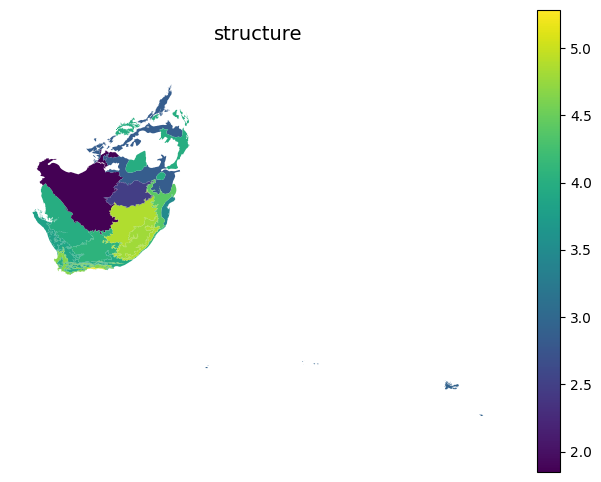

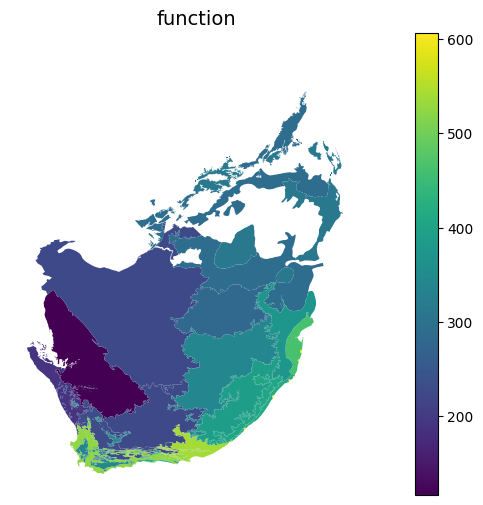

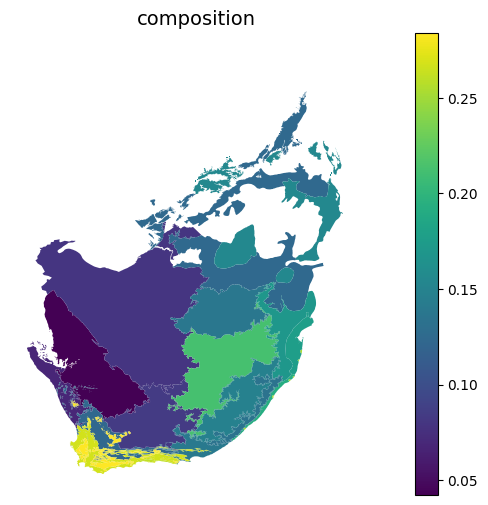

In [29]:
from matplotlib import pyplot as plt

# Plot each one
for var in ['structure', 'function', 'composition']:
    fig, ax = plt.subplots(figsize=(8, 6))
    converted.plot(column=var, legend=True, cmap='viridis', ax=ax)
    ax.set_title(var, fontsize=14)
    ax.axis('off')
    plt.show()

In [30]:
sds = gpd.read_file('data/ecoregion_sds.geojson')

In [12]:
bandNames = covariates.bandNames()

sds = ee.Dictionary({
    "composition": 0.186531332875766,
    "function": 232.11971929197887,
    "structure": 4.033266525122315
})

standardised = ee.ImageCollection(bandNames.map(lambda band: covariates.select([band]).divide(ee.Image.constant(sds.get(band))))).toBands()
standardised


In [13]:
Map.addLayer(ecoregion, {}, 'Ecoregion', False)
Map

Map(bottom=5112.0, center=[-30, 25], controls=(WidgetControl(options=['position', 'transparent_bg'], position=…

In [352]:
# -----------------------------
# Parameters
# -----------------------------
n = 200
nClusters = 100
clusterSeq = ee.List.sequence(0, nClusters - 1)
geometry = ecoregion.geometry().bounds()  # define your geometry
clipped = covariates.clip(geometry)       # your multiband image
Map.addLayer(clipped, {}, 'clipped', False)
Map

# -----------------------------
# Generate random points & sample data
# -----------------------------
pts = ee.FeatureCollection.randomPoints(geometry, n, 42, 30)
initData = clipped.addBands(ag_bin.rename('class')).sampleRegions(collection=pts, scale=30).filter(ee.Filter.neq('class', 0))
Map.addLayer(pts, {}, 'Sample points', False)

md = ee.Classifier.minimumDistance(metric = 'mahalanobis').train(features = initData, classProperty = 'class', inputProperties = clipped.bandNames()).setOutputMode('RAW')#'CLASSIFICATION'
Map.addLayer(clipped.classify(md).arrayFlatten([['ag']]), {}, 'MD classification', False)
Map

Map(bottom=5056.0, center=[-27.839076094777816, 29.794921875000004], controls=(WidgetControl(options=['positio…

In [351]:
covariates.sampleRegions(collection=pts.limit(10), scale=30).classify(md)#.arrayFlatten([['non_ag','ag']])